In [19]:
import omics_topic
import muon as mu
import torch
import scanpy as sc
import numpy as np

In [20]:
mdata = mu.read_h5mu("/scratch/fcaretti/GSE158013/GSM5123951.h5mu")
mdata_original = mdata.copy()

/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0

In [21]:
mdata.mod["prot"].X = mdata.mod["prot"].layers["counts"]
mdata.mod["rna"].X = mdata.mod["rna"].layers["counts"]
mdata.mod["atac"].X = mdata.mod["atac"].layers["counts"]

In [22]:
sc.pp.normalize_per_cell(mdata["rna"])
sc.pp.log1p(mdata["rna"])
sc.pp.highly_variable_genes(mdata["rna"], n_top_genes=1000, subset=True)
sc.pp.pca(mdata["rna"], n_comps=50, use_highly_variable=False)
sc.pp.neighbors(mdata["rna"], n_neighbors=10)
sc.tl.umap(mdata["rna"])

/tmp/ipykernel_2499418/3527809748.py:1: FutureWarning: Use sc.pp.normalize_total instead
  sc.pp.normalize_per_cell(mdata['rna'])
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/scanpy/preprocessing/_simple.py:591: FutureWarning: Use sc.pp.normalize_total instead
  normalize_per_cell(
adata.X seems to be already log-transformed.
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(adata, mask_var, use_highly_variable)


In [23]:
mdata_original["rna"].var["highly_variable"] = mdata["rna"].var["highly_variable"]
mdata["rna"].X = mdata["rna"].layers["counts"]

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mod_weights = {"rna": 1, "protein": 20, "chromatin": 1 / 90}

In [25]:
model = omics_topic.models.SVEM_LDA_Multi(
    mdata,
    n_topics=10,
    device=device,
    feature_frac=0.25,  # 25 % genes per batch
    entropy_penalty=0.1,
    alpha=0.01,
    mod_weights=mod_weights,
)

Initializing model with the following modalities: ['rna', 'chromatin', 'protein']


In [26]:
model.fit(n_epochs=20, lr_mult=0.99)

epoch 1: 100%|██████████| 12/12 [00:02<00:00,  4.48it/s]


epoch   1 | perplexity ≈ 31.4033 | elbo ≈ -10114466.3125 | 


epoch 2: 100%|██████████| 12/12 [00:03<00:00,  3.44it/s]


epoch   2 | perplexity ≈ 57.9894 | elbo ≈ -11773069.5694 | 


epoch 3: 100%|██████████| 12/12 [00:02<00:00,  5.85it/s]


...

epoch  18 | perplexity ≈ 173.2027 | elbo ≈ -15854404.8056 | 


epoch 19: 100%|██████████| 12/12 [00:02<00:00,  4.47it/s]


epoch  19 | perplexity ≈ 179.2938 | elbo ≈ -15401915.3153 | 


epoch 20: 100%|██████████| 12/12 [00:02<00:00,  4.65it/s]

epoch  20 | perplexity ≈ 164.7843 | elbo ≈ -15256163.0944 | 


In [27]:
mdata_original.obsm["topic_proportions"] = model.cell_topic_distribution().cpu().numpy()
mdata_original.obs["topic"] = np.argmax(model.cell_topic_distribution().cpu().numpy(), axis=1)

In [28]:
sc.pp.neighbors(mdata_original, use_rep="topic_proportions", key_added="omicstopic", n_neighbors=10)
sc.tl.umap(mdata_original, min_dist=0.2, neighbors_key="omicstopic")

/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/muon/_core/plot.py:239: ImplicitModificationWarning: X should not be a np.matrix, use np.ndarray instead.
  fmod_adata.X = x.todense() if issparse(x) else x
/scratch/fcaretti/omics_topic_uv/lib/python3.12/site-packages/muon/_core/plot.py:239: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  fmod_adata.X = x.todense() if issparse(x) else x


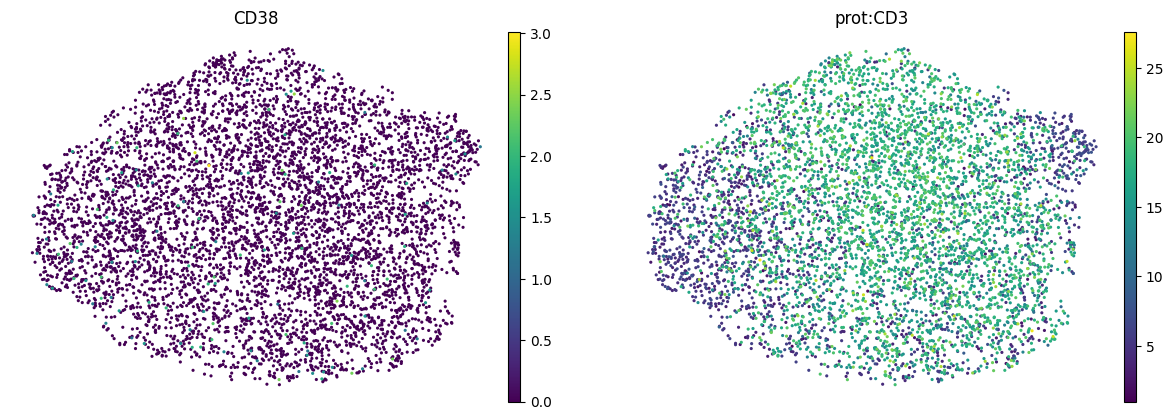

In [29]:
mu.pl.umap(mdata_original, color=["CD38", "prot:CD3"], layer={"rna": "lognorm"}, frameon=False, cmap="viridis")

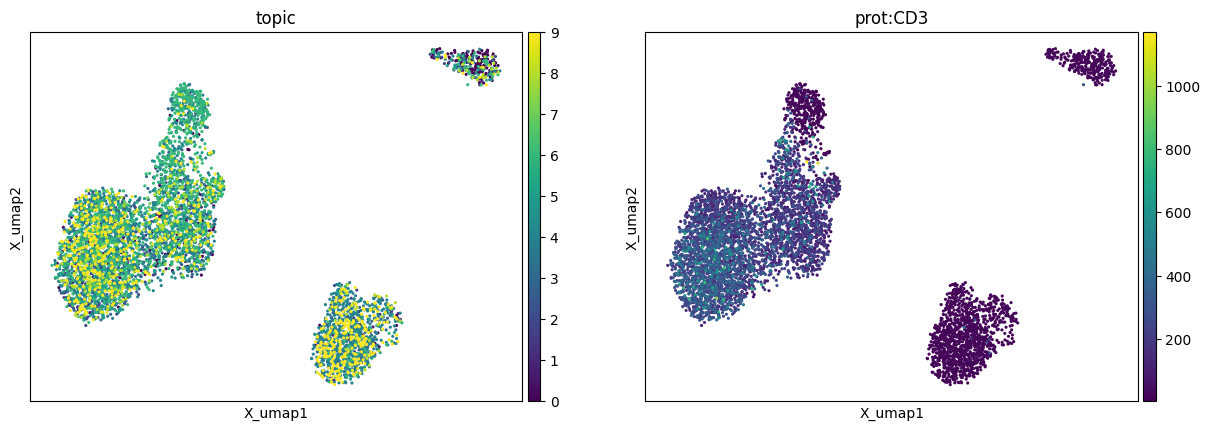

In [30]:
rna = mdata["rna"].copy()
mdata.obsm["topic_proportions"] = model.cell_topic_distribution().cpu().numpy()
mdata.obs["topic"] = np.argmax(model.cell_topic_distribution().cpu().numpy(), axis=1)
mu.pl.embedding(mdata, basis="rna:X_umap", color=["topic", "prot:CD3"])

IndexError: index 10 is out of bounds for axis 1 with size 10

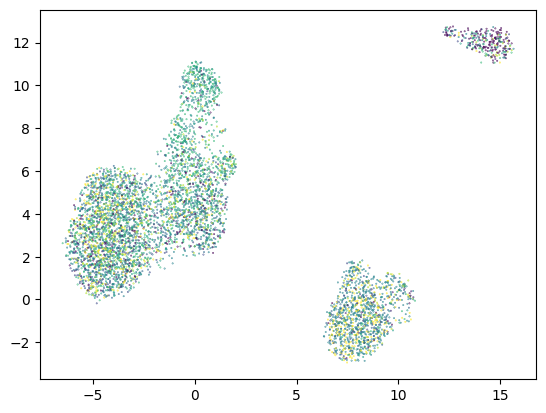

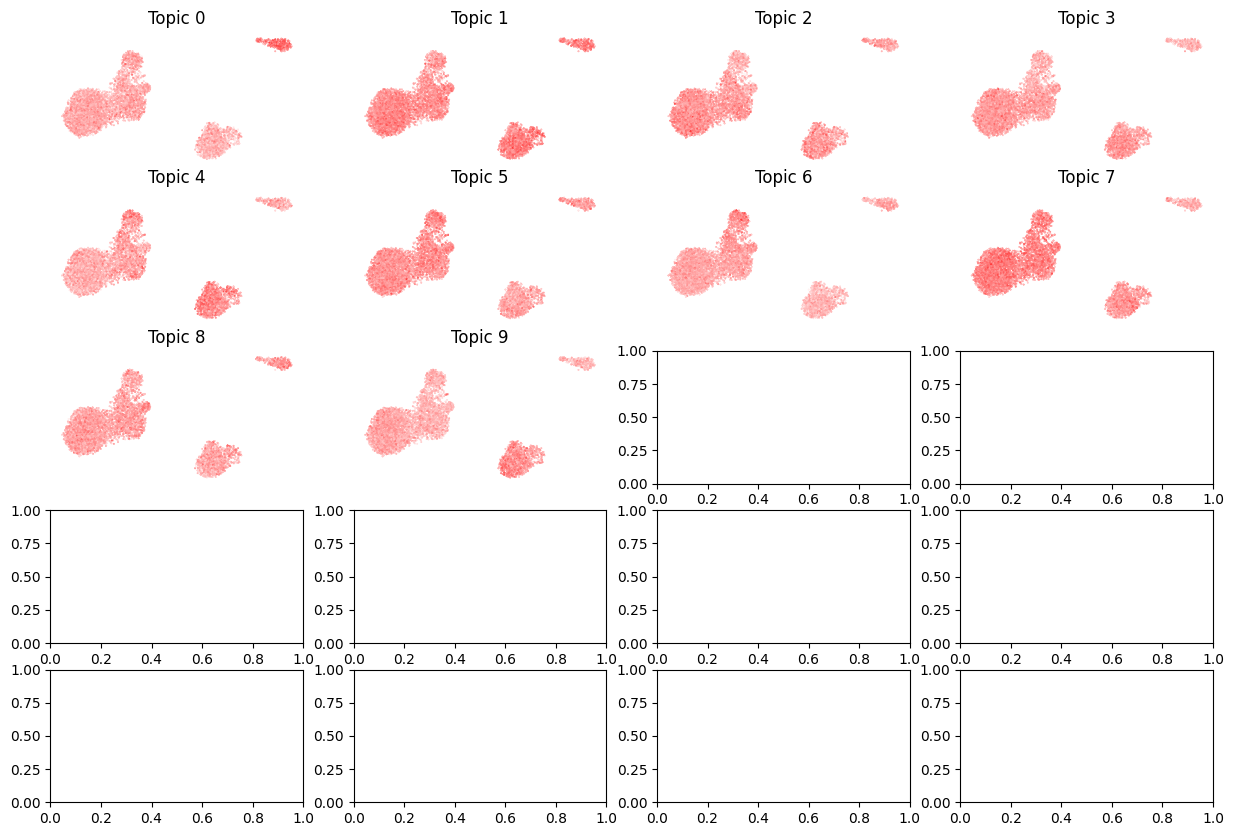

In [31]:
import matplotlib.colors as clt
import matplotlib.pyplot as plt

plt.scatter(rna.obsm["X_umap"][:, 0], rna.obsm["X_umap"][:, 1], c=mdata.obs["topic"], s=0.1)

cmap = clt.LinearSegmentedColormap.from_list("wr", ("white", "red"))
vmin, vmax = mdata.obsm["topic_proportions"].min(), mdata.obsm["topic_proportions"].max()
samples_mean = model.cell_topic_distribution().cpu().numpy()

fig, ax = plt.subplots(5, 4, figsize=(15, 10))
for i in range(5):
    for j in range(4):
        ax[i, j].scatter(
            rna.obsm["X_umap"][:, 0], rna.obsm["X_umap"][:, 1], c=samples_mean[:, i * 4 + j], cmap=cmap, s=0.1
        )
        ax[i, j].set_title(f"Topic {i * 4 + j}")
        ax[i, j].axis("off")